# Simulación de una tarea con contacto

## Setup

In [13]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

from scipy.integrate import solve_ivp
import roboticstoolbox as rtb
import spatialmath as sm
from tqdm import tqdm 
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')


In [5]:
# Preparo el modelo de un doble péndulo
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=200e-3,m=1.5,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-3]),
                B=0.1, G=1),
        rtb.RevoluteDH(a=200e-3,m=1,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-3]),
                B=0.1, G=1),
    ],
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name = "DoblePendulo")

qr = np.array([-np.pi/2,0])
qz = np.zeros((2,))

print(dp)
print(dp.dynamics())


DHRobot: DoblePendulo, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬────────────────────────────┬────┬──────┬────────┬────┐
│   j   │  m   │      r       │             I              │ Jm │  B   │   Tc   │ G  │
├───────┼──────┼──────────────┼────────────────────────────┼────┼──────┼────────┼────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0 │  0 │  0.1 │  0,  0 │  1 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0 │  0 │  0.1 │  0,  0 │  1 │
└───────┴──────┴──────────────┴────────────────────────────┴────┴──────┴────────┴────┘

None


In [ ]:
# Muestro la animación del robot

def dp_animate(q, Ts=0.1, trail=False, interval=None):
    """
    Animación de doble péndulo a partir de coordenadas articulares

    Parámetros:
    - q: array (nq, N) trayectoria articular
    - Ts: paso de tiempo (s)
    - trail: True para dejar traza del extremo
    - interval: ms entre frames (default = Ts*1000)

    Retorna:
    - HTML para visualizar en notebook
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    plt.rcParams["animation.html"] = "html5"

    N = q.shape[0]

    # --- calcular posiciones ---
    xy_codo = np.zeros((N, 3))
    xy_tool = np.zeros((N, 3))

    for i in range(N):
        q_i = q[i,:]

        T = dp.fkine_all(q_i)
        
        T_codo = T[1]
        T_tool = T[2]
        xy_codo[i, :] = T_codo.t
        xy_tool[i, :] = T_tool.t

    # base
    x0, y0 = 0.0, 0.0

    x1, y1 = xy_codo[:, 0], xy_codo[:, 1]
    x2, y2 = xy_tool[:, 0], xy_tool[:, 1]

    # --- figura ---
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    all_x = np.concatenate(([x0], x1, x2))
    all_y = np.concatenate(([y0], y1, y2))
    margin = 0.2

    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)

    line, = ax.plot([], [], 'o-', lw=2)
    trail_line = None
    top_line = None

    if trail:
        trail_line, = ax.plot([], [], '-', alpha=0.3)
        top_line, = ax.plot([], [], '-', alpha=0.3)

    # --- animación ---
    def init():
        line.set_data([], [])
        if trail_line:
            trail_line.set_data([], [])
            top_line.set_data([], [])
            return line, trail_line, top_line
        return (line,)

    def update(i):
        xs = [x0, x1[i], x2[i]]
        ys = [y0, y1[i], y2[i]]

        line.set_data(xs, ys)

        if trail_line:
            trail_line.set_data([-0.6,0.6],[y_techo,y_techo])
            top_line.set_data(x2[:i], y2[:i])
            return line, trail_line, top_line

        return (line,)

    if interval is None:
        interval = Ts * 1000

    ani = FuncAnimation(fig, update,
                        frames=N,
                        init_func=init,
                        interval=interval,
                        blit=True)

    plt.close(fig)

    return HTML(ani.to_html5_video())


## Definición de la tarea

In [166]:
q_ini = np.r_[np.pi/4,0]
q_fin = np.r_[np.pi/2,0]

POSE_ini = dp.fkine(q_ini)

# Configuro la base de tiempo de la simulación
dt = 1e-3
n_samples = 1000
t = np.arange(0,n_samples * dt,dt)

# Calculo offline las referencias
q_des = rtb.mtraj(rtb.trapezoidal, q_ini, q_fin, t).q

# Amplio el vector para dar más tiempo para llegar
n_extra = 1000
q_des = np.vstack([
    q_des,
    np.tile(q_des[-1], (n_extra, 1))
])
# actualizo tiempo y cantidad de muestras
n_samples = len(q_des)
t = np.arange(n_samples) * dt


## Modelo del contacto

In [165]:
# Parámetros del modelo del contacto
y_techo = POSE_ini.t[1]+0.03

k_contact = 5000.0      # N/m
b_contact = 50.0        # Ns/m

def contacto(q, qd):

    T = dp.fkine(q)
    p = T.t

    J = dp.jacob0(q)[0:2, :]      # Jacobiano planar x,y

    v = J @ qd
    vy = v[1]

    penetracion = p[1] - y_techo

    if penetracion > 0:        
        Fy = -k_contact * penetracion - b_contact * vy
        Fy = np.min((0,Fy))
    else:
        Fy = 0

    return J.T @ np.r_[0.0, Fy], Fy

## Modelo de la dinámica directa

In [ ]:
def f_dynamics(t, x, tau):
    n = len(x)//2
    q = x[:n]
    qd = x[n:]

    tau_c,_ = contacto(q,qd)
    qdd = dp.accel(q,qd,tau+tau_c)

    return np.hstack((qd, qdd))

## Simulación control de posición

Probamos compliance pasiva aflojando las ganancias del control del segundo eje

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:14<00:00, 139.04it/s]


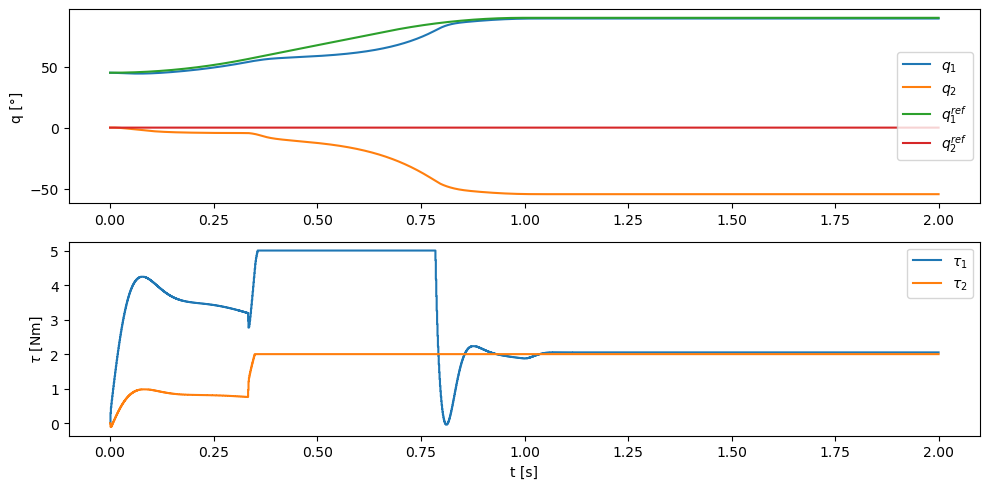

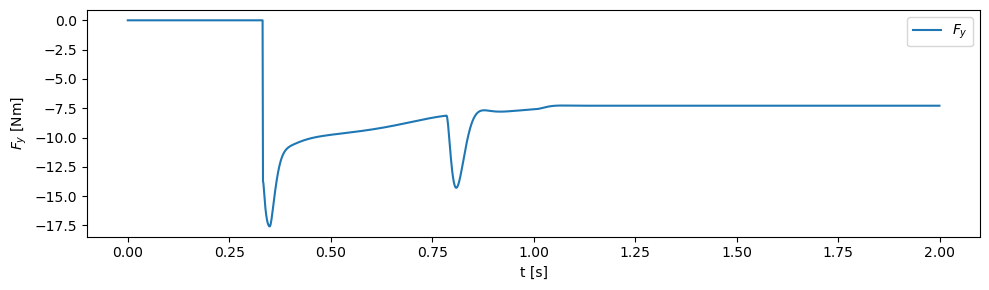

In [179]:
# Ganancias del controlador
Kp = np.diag([200, 10]) 
Kd = np.diag([5, 1])

# Límites del actuador
tau_max = np.array([5.0, 2.0])   # Nm

# Condición inicial
q = q_ini
qd = np.zeros_like(q)
x = np.hstack((q,qd))

# Defino vectores para almacenar datos 
q_samples = np.zeros((n_samples,len(q)))
qd_samples = np.zeros((n_samples,len(q)))
tau_samples = np.zeros((n_samples,len(q)))
Fy_samples = np.zeros(n_samples)

# Cuando se realiza el primer contacto pasamos a controlar fuerza en y
for i in tqdm(range(n_samples)):
    # Obtengo la referencia para el instante actual
    q_ref = q_des[i]

    # Calculo la fuerza de contacto
    _, Fy = contacto(x[:2], x[2:])

    # Calculo la acción de control para el instante de tiempo actual
    tau_pd = Kp.dot(q_ref - x[:2]) - Kd.dot(x[2:]) #+ dp.gravload(x[:2])  
    tau_pd = np.clip(tau_pd, -tau_max, tau_max) 

    # Integración de tiempo continuo en un paso con tau constante
    sol = solve_ivp(
        lambda t, x_: f_dynamics(t, x_, tau_pd),
        [0, dt],
        x,
        method='RK45',
        t_eval=[dt],   # solo me interesa el final
        rtol=1e-6,
        atol=1e-9
    )

    # Actualizo los estados
    x = sol.y[:,-1]

    # Almaceno resultados para graficar luego
    q_samples[i,:] = x[:2]
    qd_samples[i,:] = x[2:]
    tau_samples[i,:] = tau_pd
    Fy_samples[i] = Fy


plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,q_samples*180/np.pi)
plt.plot(t,q_des*180/np.pi)
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$q^{ref}_1$',r'$q^{ref}_2$'])
plt.subplot(2,1,2)
plt.step(t,tau_samples,where='post')
plt.legend([r'$\tau_1$',r'$\tau_2$'])
plt.ylabel(r'$\tau$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(t,Fy_samples,label='$F_y$')
plt.legend()
plt.ylabel(r'$F_y$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

dp_animate(q_samples[0:-1:20],Ts=dt*20,trail=True)

## Simulación control de fuerzas

Implementamos un control de fuerzas híbrido, y buscamos que la fuerza aplicada sobre la superficie siga un objetivo de referencia.

100%|██████████| 2000/2000 [00:14<00:00, 139.16it/s]


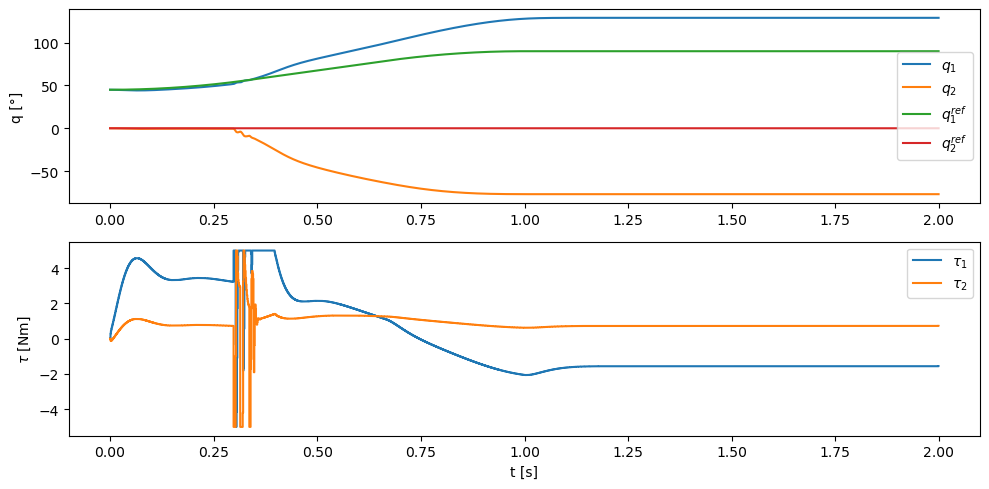

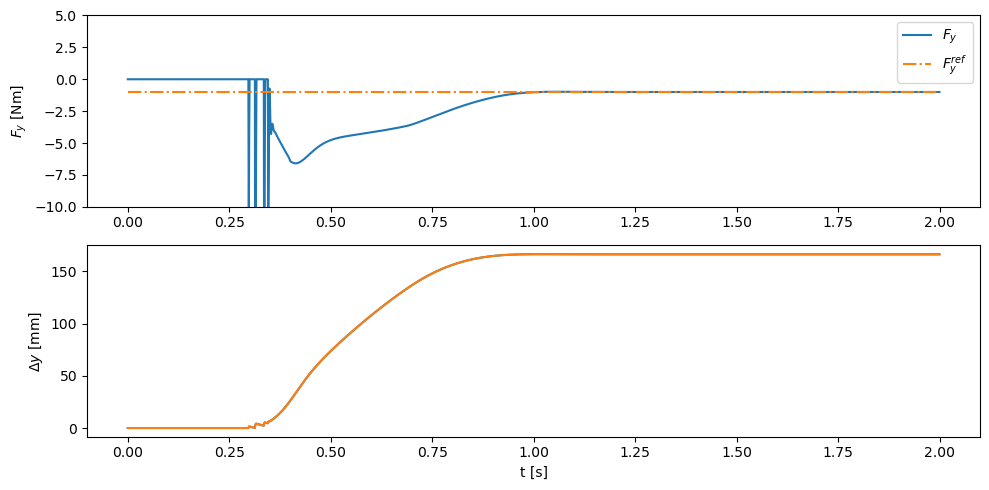

In [ ]:
# Ganancias del controlador
Kp = np.diag([200, 100]) 
Kd = np.diag([5, 1])

# Límites del actuador
tau_max = np.array([5.0, 5.0])   # Nm

# Condición inicial
q = q_ini
qd = np.zeros_like(q)
x = np.hstack((q,qd))

# Defino vectores para almacenar datos 
q_samples = np.zeros((n_samples,len(q)))
deltaY_samples = np.zeros_like(q_samples)
qd_samples = np.zeros((n_samples,len(q)))
tau_samples = np.zeros((n_samples,len(q)))
Fy_samples = np.zeros(n_samples)

# Cuando se realiza el primer contacto pasamos a controlar fuerza en y
flag_contacto = False
flag_control_fuerzas = True
for i in tqdm(range(n_samples)):
    # Obtengo la referencia para el instante actual
    q_ref = q_des[i]

    # Calculo la fuerza de contacto
    _, Fy = contacto(x[:2], x[2:])

    # Si aparece el contacto, voy a corregir las referencias para que la Fy sea de 1N
    if  Fy<-0 and not flag_contacto:
        flag_contacto = True

    if flag_control_fuerzas and flag_contacto:
        Fy_ref = -1
        Kf = 1/k_contact * 500.0
        DeltaY += Kf * (Fy_ref-Fy) *dt
        J = dp.jacob0(x[:2])[0:2, :]
        DeltaQ = np.linalg.pinv(J) @ np.r_[0,DeltaY]
    else:
        DeltaY = 0
        DeltaQ = np.zeros_like(q_ref)

    # Calculo la acción de control para el instante de tiempo actual
    tau_pd = Kp.dot(q_ref - DeltaQ - x[:2]) - Kd.dot(x[2:]) #+ dp.gravload(x[:2])  
    tau_pd = np.clip(tau_pd, -tau_max, tau_max) 

    # Integración de tiempo continuo en un paso con tau constante
    sol = solve_ivp(
        lambda t, x_: f_dynamics(t, x_, tau_pd),
        [0, dt],
        x,
        method='RK45',
        t_eval=[dt],   # solo me interesa el final
        rtol=1e-6,
        atol=1e-9
    )

    # Actualizo los estados
    x = sol.y[:,-1]

    # Almaceno resultados para graficar luego
    deltaY_samples[i,:] = DeltaY
    q_samples[i,:] = x[:2]
    qd_samples[i,:] = x[2:]
    tau_samples[i,:] = tau_pd
    Fy_samples[i] = Fy


plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,q_samples*180/np.pi)
plt.plot(t,q_des*180/np.pi)
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$q^{ref}_1$',r'$q^{ref}_2$'])
plt.subplot(2,1,2)
plt.step(t,tau_samples,where='post')
plt.legend([r'$\tau_1$',r'$\tau_2$'])
plt.ylabel(r'$\tau$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,Fy_samples,label='$F_y$')
plt.plot([t[0],t[-1]],[Fy_ref,Fy_ref],'-.',label=r'$F_y^{ref}$')
plt.legend()
plt.ylabel(r'$F_y$ [Nm]')
plt.ylim((-10,5))
plt.subplot(2,1,2)
plt.plot(t,deltaY_samples*1000.0)
plt.ylabel(r'$\Delta y$ [mm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

dp_animate(q_samples[0:-1:20],Ts=dt*20,trail=True)